In [36]:
import torch
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

In [37]:
# 입력크기 300*300
model=torchvision.models.detection.ssd300_vgg16(pretrained=True)
# 평가모드로 전환
model.eval()

/home/hi/miniconda3/envs/torch_env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/hi/miniconda3/envs/torch_env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SSD300_VGG16_Weights.COCO_V1`. You can also use `weights=SSD300_VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


SSD(
  (backbone): SSDFeatureExtractorVGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=

In [38]:
COCO_NAMES=[
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella',
    'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
    'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard',
    'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon',
    'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot',
    'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant',
    'bed', 'mirror', 'dining table', 'window', 'desk', 'toilet', 'door',
    'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave',
    'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase',
    'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

In [86]:
img_path='images/DLguys.jpeg'
img=Image.open(img_path).convert('RGB')

In [87]:
transform=transforms.Compose([
    transforms.Resize((300,300)),
    transforms.ToTensor(),
])

In [88]:
in_tensor=transform(img)
print(in_tensor.dim())
in_tensor=in_tensor.unsqueeze(0)
in_tensor.shape

3


torch.Size([1, 3, 300, 300])

In [89]:
in_tensor.dim()

4

In [90]:
# 모델 추론
with torch.inference_mode():
    pred=model(in_tensor)[0]

# 바운딩 박스(각 사물의 위치 4개 -xmin, ymin, xmax, ymax)
box1=pred['boxes']
print(box1)

# 클래스 번호
label1=pred['labels']
print(label1)

# 신뢰도
scores1=pred['scores']
print(scores1)

tensor([[1.4717e+02, 7.3198e+01, 2.2055e+02, 3.0000e+02],
        [0.0000e+00, 7.4139e+01, 9.0837e+01, 2.9993e+02],
        [8.1661e+01, 7.1714e+01, 1.5452e+02, 3.0000e+02],
        [2.0871e+02, 7.3396e+01, 2.9253e+02, 2.9683e+02],
        [5.9495e+01, 1.0565e+02, 7.7167e+01, 1.3961e+02],
        [1.1526e+02, 4.8560e+01, 1.1964e+02, 7.0503e+01],
        [1.2167e+02, 4.6549e+01, 1.2758e+02, 6.8744e+01],
        [3.6193e+01, 1.3540e+02, 7.0350e+01, 1.9590e+02],
        [1.2912e+02, 4.2507e+01, 1.3358e+02, 6.8301e+01],
        [1.1576e+02, 4.9653e+01, 1.2333e+02, 6.8993e+01],
        [1.0766e+02, 4.9656e+01, 1.1246e+02, 7.4534e+01],
        [1.0716e+02, 4.2032e+01, 1.3662e+02, 7.5055e+01],
        [3.8474e-01, 1.2447e+02, 2.6938e+01, 1.5948e+02],
        [1.1841e+02, 4.3035e+01, 1.3030e+02, 6.6285e+01],
        [1.7128e+02, 1.3352e+02, 1.9498e+02, 2.0574e+02],
        [1.1333e+02, 4.4093e+01, 1.2423e+02, 6.4163e+01],
        [1.0108e+01, 1.2263e+02, 3.1687e+01, 1.4038e+02],
        [2.953

In [91]:
import matplotlib.patches as patches
import cv2

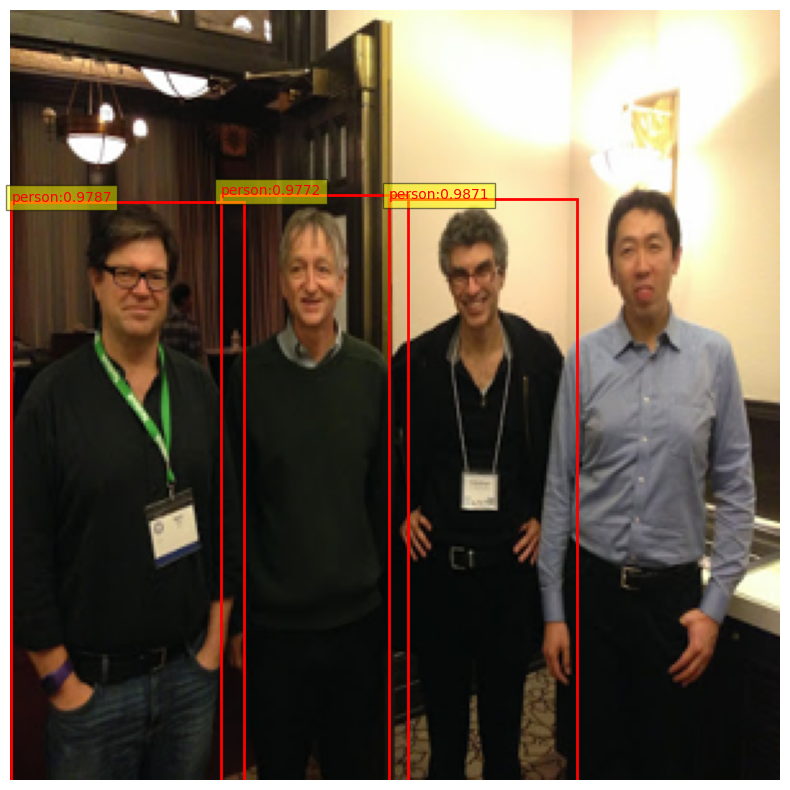

In [92]:
fig,ax=plt.subplots(1, figsize=(12,10))
ax.imshow(img.resize((300,300)))

threshold=0.5
for box, label, score in zip(box1, label1, scores1):
    if score>threshold:
        x_min, y_min, x_max, y_max=box.tolist()
        width=x_max-x_min
        height=y_max-y_min

        # 이미지 위에 사각형 생성
        # facecolor='none' : 안 색깔 채우지 않겠다.
        rect=patches.Rectangle((x_min, y_min), width, height, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)

        class_name=COCO_NAMES[label.item()]
        text=f"{class_name}:{score:.4f}"

        ax.text(x_min, y_min, text, color='red', bbox=dict(facecolor='yellow', alpha=0.5))

plt.axis('off')
plt.show()